In [2]:
import pandas as pd
import matplotlib.pyplot as plt


# COMPARE WITH GPT 4.1

C:\Users\nkelesoglu\AppData\Local\Temp\ipykernel_13036\3146177159.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(comp_times, labels=labels, whis=3)


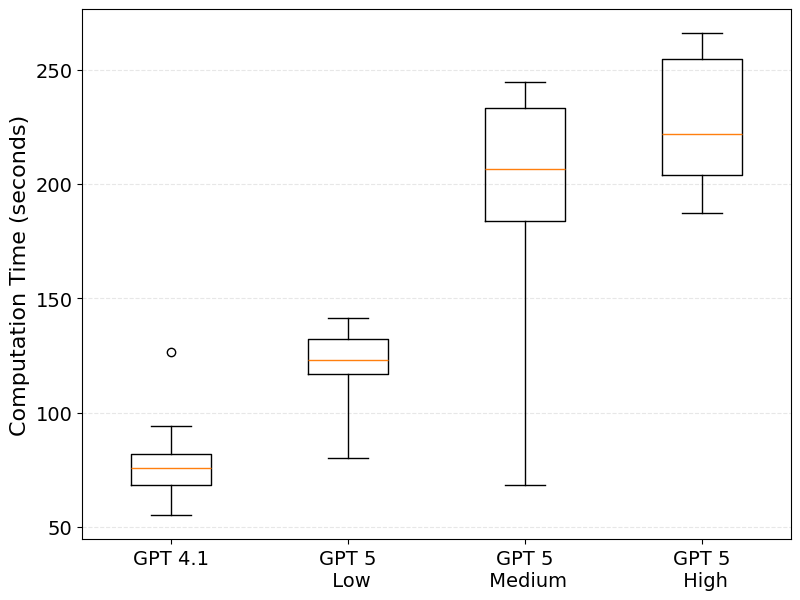

C:\Users\nkelesoglu\AppData\Local\Temp\ipykernel_13036\3146177159.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(output_tokens, labels=labels)


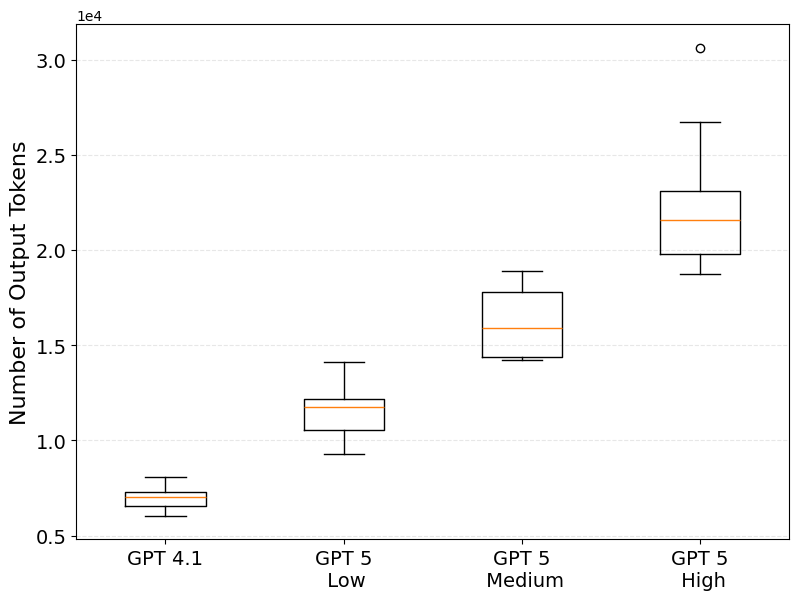

In [11]:

# ---- Load CSV files ----
# df_low = pd.read_csv("../Generated_Traffic/New_Experiments/GPT5_Exp1_Reasoning_lowww_10minute_results.csv")
df_low = pd.read_csv("../Generated_Traffic/New_Experiments/GPT5_Exp1_Reasoning_low_10minute_results_second.csv")
df_med = pd.read_csv("../Generated_Traffic/New_Experiments/GPT5_Exp1_Reasoning_medium_10minute_results.csv")
df_high = pd.read_csv("../Generated_Traffic/New_Experiments/GPT5_Exp1_Reasoning_high_10minute_results.csv")
df_41 = pd.read_csv("../Generated_Traffic/New_Experiments/GPT41_Exp1_10minute_results.csv")

df_med_clean = df_med[df_med["Computation_Time"] != df_med["Computation_Time"].max()]
df_med = df_med_clean.copy()

# ---- Prepare data in dict form ----
comp_times = [
    df_41["Computation_Time"],
    df_low["Computation_Time"],
    df_med["Computation_Time"],
    df_high["Computation_Time"]
]

output_tokens = [
    df_41["Output_Tokens"],
    df_low["Output_Tokens"],
    df_med["Output_Tokens"],
    df_high["Output_Tokens"]
]

labels = ["GPT 4.1", "GPT 5\n Low", "GPT 5\n Medium", "GPT 5\n High"]

# ---- Plot Computation Time boxplot ----
plt.figure(figsize=(8, 6))
plt.boxplot(comp_times, labels=labels, whis=3)
#plt.title("GPT-5 Reasoning Effort Comparison — Computation Time", fontsize=14)
plt.ylabel("Computation Time (seconds)", fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.savefig("gpts_time.png", dpi=300)
plt.show()

# ---- Plot Output Tokens boxplot ----
plt.figure(figsize=(8, 6))
plt.boxplot(output_tokens, labels=labels)

plt.ylabel("Number of Output Tokens", fontsize=16)

# ⭐ Force scientific notation (e.g., ×10³)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)

plt.savefig("gpts_output_tokens.png", dpi=300)
plt.show()

## STATISCTICS

In [12]:
import json
real_traffic = []
with open(r'../Datasets/Experiment_1_one_way_communication_10_minute_input_sample.json', 'r') as file:
    for line in file:
        real_traffic.append(json.loads(line))

real_traffic  = pd.DataFrame(real_traffic)
real_traffic = real_traffic.drop(columns=["No.", "Info_clean"])


In [13]:
Real_Inter_Arrival = real_traffic["Time"].astype(float).diff().dropna().values.tolist()

In [14]:
import pandas as pd

import os
import numpy as np
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

def distribution_similarity(real_traffic, gen_traffic, bins=10):

    # Normalization and Histogram
    real_hist, _ = np.histogram(real_traffic, bins=bins, density=True)
    gen_hist, _ = np.histogram(gen_traffic, bins=bins, density=True)

    # Prevent zeros by adding lower case numbers
    """Jensen-Shannon Divergence can have problems with histograms containing zeros (log(0) is undefined). 
    Therefore, a small number (1e-9) is added to the histograms to remove the zeros."""
    real_hist += 1e-9
    gen_hist += 1e-9

    # Similarity Calculation
    """Jensen-Shannon Divergence (JSD): Measures the similarity between two probability distributions 
    (0: exactly the same, 1: completely different)."""
    js = jensenshannon(real_hist, gen_hist)

    return js

In [21]:
# ----------------------------   GPT 4.1   --------------------------------------

N = [1,2,3,4,5,6,7,8,9,10]

num_pac = []
pack_size = []
time_mean = []
time_min = []
time_max = []
JS_metric = []
gpt41_intervals = [] 

for n in N:
    #file_path = fr"../Generated_Traffic/GPT4.1_Reasoning_Exp1_Trial_{n}_10_minute_generated_message.json"
    file_path = fr"../Generated_Traffic/New_Experiments/GPT41/GPT41_Exp1_Trial_{n}_10_minute_generated_message.json"

    # df_med_clean = df_med[df_med["Computation_Time"] != df_med["Computation_Time"].max()]
    # df_med = df_med_clean.copy()


    with open(file_path, 'r') as f:
        generated_traffic = json.load(f)

        
    print(generated_traffic)
    generated_traffic = pd.DataFrame(generated_traffic)

    # data = json.loads(generated_traffic)  # Convert string to Python list
    # generated_traffic = pd.DataFrame(data)

    #generated_traffic =  pd.DataFrame(generated_traffic)
    # generated_traffic.head(2)
    # generated_traffic = pd.DataFrame(generated_traffic[2:-2])
    #generated_traffic.head(2)

    print(f"\n ================== Generated Traffic Trial Number {n} ==================")      

    print("Number of Packet:", len(generated_traffic))
    print("Average Packet Size:", (generated_traffic['length'].astype(int)).mean())
    print("Time Interval Average:", (generated_traffic['time'].astype(float)).diff().mean())
    print("Time Interval min:", (generated_traffic['time'].astype(float)).diff().min())
    print("Time Interval max:", (generated_traffic['time'].astype(float)).diff().max())
    print("Number of source:", generated_traffic['src'].nunique())
    print("Number of destination:", generated_traffic['dst'].nunique())
    
    num_pac.append(len(generated_traffic))
    pack_size.append((generated_traffic['length'].astype(int)).mean())
    Inter_Arrival = generated_traffic["time"].astype(float).diff().dropna().values.tolist()
    gpt41_intervals.extend(Inter_Arrival)
    #print(Inter_Arrival)

    time_mean.append((generated_traffic['time'].astype(float)).diff().mean())
    time_min.append((generated_traffic['time'].astype(float)).diff().min())
    time_max.append((generated_traffic['time'].astype(float)).diff().max())


    """ JENSEN SHANNON FOR TIMESTAMPT"""

    generated_traffic['time'] = pd.to_numeric( generated_traffic['time'], errors='coerce')
    real_traffic['Time'] = pd.to_numeric(real_traffic['Time'], errors='coerce')

    js_packet = distribution_similarity(real_traffic['Time'], generated_traffic['time'] )
    print(f"\nJensen-Shannon for time: {js_packet:.4f}")
    JS_metric.append(js_packet)
    

gpt41_num_pac = num_pac
gpt41_JS = JS_metric

print("Number of Packet:", np.mean(num_pac),  
    "Average Packet Size", np.mean(pack_size),
    "Time Interval Average", np.mean(time_mean),
    "Time Interval min",  np.mean(time_min),
    "Time Interval max",  np.mean(time_max),
     "Average JS:", np.mean(JS_metric)
    )

print(JS_metric)

[{'time': '0.000', 'src': '0x1de6', 'dst': '0xfffc', 'protocol': 'ZigBee', 'length': '80', 'info': 'Link Status'}, {'time': '7.982', 'src': '0x1de6', 'dst': '0xd7a7', 'protocol': 'ZigBee HA', 'length': '69', 'info': 'ZCL: Read Attributes Response, Seq: 4'}, {'time': '8.010', 'src': '0x1de6', 'dst': '0xd7a7', 'protocol': 'ZigBee HA', 'length': '61', 'info': 'ZCL: Read Attributes Response, Seq: 5'}, {'time': '14.187', 'src': '0x1de6', 'dst': '0xfffc', 'protocol': 'ZigBee', 'length': '80', 'info': 'Link Status'}, {'time': '21.053', 'src': '0x1de6', 'dst': '0xd7a7', 'protocol': 'ZigBee HA', 'length': '69', 'info': 'ZCL: Read Attributes Response, Seq: 29'}, {'time': '21.082', 'src': '0x1de6', 'dst': '0xd7a7', 'protocol': 'ZigBee HA', 'length': '61', 'info': 'ZCL: Read Attributes Response, Seq: 30'}, {'time': '28.402', 'src': '0x1de6', 'dst': '0xfffc', 'protocol': 'ZigBee', 'length': '80', 'info': 'Link Status'}, {'time': '34.192', 'src': '0x1de6', 'dst': '0xd7a7', 'protocol': 'ZigBee HA', '

## gpt 5 low

In [25]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import jensenshannon

N = [1,2,3,4,5,6,7,8,9,10]

num_pac = []
pack_size = []
time_mean = []
time_min = []
time_max = []
JS_metric = []
low_intervals = [] 

for n in N:
    # file_path = fr"../Generated_Traffic/GPT5_Reasoning_low_Exp1_Trial_{n}_10_minute_generated_message.json"
    file_path = fr"../Generated_Traffic/New_Experiments/GPT5/GPT5_Exp1_Reasoning_low_Trial_{n}_10_minute_generated_message_second.json"


    with open(file_path, 'r') as f:
        generated_traffic = json.load(f)

        
    # generated_traffic

    # data = json.loads(generated_traffic)  # Convert string to Python list
    generated_traffic = pd.DataFrame(generated_traffic)

    print(f"\n ================== Generated Traffic Trial Number {n} ==================")      

    print("Number of Packet:", len(generated_traffic))
    print("Average Packet Size:", (generated_traffic['length'].astype(int)).mean())
    print("Time Interval Average:", (generated_traffic['time'].astype(float)).diff().mean())
    print("Time Interval min:", (generated_traffic['time'].astype(float)).diff().min())
    print("Time Interval max:", (generated_traffic['time'].astype(float)).diff().max())
    print("Number of source:", generated_traffic['src'].nunique())
    print("Number of destination:", generated_traffic['dst'].nunique())
    
    num_pac.append(len(generated_traffic))
    pack_size.append((generated_traffic['length'].astype(int)).mean())
    Inter_Arrival = generated_traffic["time"].astype(float).diff().dropna().values.tolist()
    low_intervals.extend(Inter_Arrival)
    #print(Inter_Arrival)

    time_mean.append((generated_traffic['time'].astype(float)).diff().mean())
    time_min.append((generated_traffic['time'].astype(float)).diff().min())
    time_max.append((generated_traffic['time'].astype(float)).diff().max())


    """ JENSEN SHANNON FOR TIMESTAMPT"""

    generated_traffic['time'] = pd.to_numeric( generated_traffic['time'], errors='coerce')
    real_traffic['Time'] = pd.to_numeric(real_traffic['Time'], errors='coerce')

    js_packet = distribution_similarity(real_traffic['Time'], generated_traffic['time'] )
    print(f"\nJensen-Shannon for time: {js_packet:.4f}")
    JS_metric.append(js_packet)
    

low_num_pac = num_pac
low_JS = JS_metric

print("Number of Packet:", np.mean(num_pac),  
    "Average Packet Size", np.mean(pack_size),
    "Time Interval Average", np.mean(time_mean),
    "Time Interval min",  np.mean(time_min),
    "Time Interval max",  np.mean(time_max),
     "Average JS:", np.mean(JS_metric)
    )

print(JS_metric)


 ================== Generated Traffic Trial Number 1 ==================
Number of Packet: 196
Average Packet Size: 66.5
Time Interval Average: 3.0589743589743588
Time Interval min: 0.025683999999998264
Time Interval max: 8.757809999999992
Number of source: 1
Number of destination: 2

Jensen-Shannon for time: 0.1060

 ================== Generated Traffic Trial Number 2 ==================
Number of Packet: 130
Average Packet Size: 69.36153846153846
Time Interval Average: 4.635658914728682
Time Interval min: 0.028632000000001767
Time Interval max: 15.250622999999905
Number of source: 1
Number of destination: 2

Jensen-Shannon for time: 0.1074

 ================== Generated Traffic Trial Number 3 ==================
Number of Packet: 137
Average Packet Size: 69.22627737226277
Time Interval Average: 4.411691176470589
Time Interval min: 0.027532000000007884
Time Interval max: 13.735343999999998
Number of source: 1
Number of destination: 2

Jensen-Shannon for time: 0.0821

 ==================

## MEDIUM

In [28]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import jensenshannon

N = [1,2,3,4,5,6,7,8,9,10]

num_pac = []
pack_size = []
time_mean = []
time_min = []
time_max = []
JS_metric = []
medium_intervals = []

for n in N:
    file_path = fr"../Generated_Traffic/New_Experiments/GPT5/GPT5_Exp1_Reasoning_medium_Trial_{n}_10_minute_generated_message.json"

    with open(file_path, 'r') as f:
        generated_traffic = json.load(f)

        
    # generated_traffic

    # data = json.loads(generated_traffic)  # Convert string to Python list
    generated_traffic = pd.DataFrame(generated_traffic)

    #generated_traffic =  pd.DataFrame(generated_traffic)
    # generated_traffic.head(2)
    # generated_traffic = pd.DataFrame(generated_traffic[2:-2])
    #generated_traffic.head(2)

    print(f"\n ================== Generated Traffic Trial Number {n} ==================")      

    print("Number of Packet:", len(generated_traffic))
    print("Average Packet Size:", (generated_traffic['length'].astype(int)).mean())
    print("Time Interval Average:", (generated_traffic['time'].astype(float)).diff().mean())
    print("Time Interval min:", (generated_traffic['time'].astype(float)).diff().min())
    print("Time Interval max:", (generated_traffic['time'].astype(float)).diff().max())
    print("Number of source:", generated_traffic['src'].nunique())
    print("Number of destination:", generated_traffic['dst'].nunique())
    
    num_pac.append(len(generated_traffic))
    pack_size.append((generated_traffic['length'].astype(int)).mean())
    Inter_Arrival = generated_traffic["time"].astype(float).diff().dropna().values.tolist()
    medium_intervals.extend(Inter_Arrival)

    time_mean.append((generated_traffic['time'].astype(float)).diff().mean())
    time_min.append((generated_traffic['time'].astype(float)).diff().min())
    time_max.append((generated_traffic['time'].astype(float)).diff().max())


    """ JENSEN SHANNON FOR TIMESTAMPT"""

    generated_traffic['time'] = pd.to_numeric( generated_traffic['time'], errors='coerce')
    real_traffic['Time'] = pd.to_numeric(real_traffic['Time'], errors='coerce')

    js_packet = distribution_similarity(real_traffic['Time'], generated_traffic['time'] )
    print(f"\nJensen-Shannon for time: {js_packet:.4f}")
    JS_metric.append(js_packet)
    
medium_num_pac = num_pac
medium_JS = JS_metric

print("Number of Packet:", np.mean(num_pac),  
    "Average Packet Size", np.mean(pack_size),
    "Time Interval Average", np.mean(time_mean),
    "Time Interval min",  np.mean(time_min),
    "Time Interval max",  np.mean(time_max),
     "Average JS:", np.mean(JS_metric)
    )

print(JS_metric)


 ================== Generated Traffic Trial Number 1 ==================
Number of Packet: 188
Average Packet Size: 68.01595744680851
Time Interval Average: 3.198600101604278
Time Interval min: 0.025286999999991622
Time Interval max: 11.740883000000004
Number of source: 1
Number of destination: 2

Jensen-Shannon for time: 0.0895

 ================== Generated Traffic Trial Number 2 ==================
Number of Packet: 144
Average Packet Size: 69.0625
Time Interval Average: 4.190741258741259
Time Interval min: -0.820999999999998
Time Interval max: 12.63300000000001
Number of source: 1
Number of destination: 2

Jensen-Shannon for time: 0.0858

 ================== Generated Traffic Trial Number 3 ==================
Number of Packet: 200
Average Packet Size: 67.85
Time Interval Average: 3.0010206984924626
Time Interval min: 0.025337999999997862
Time Interval max: 8.752628999999985
Number of source: 1
Number of destination: 2

Jensen-Shannon for time: 0.0977

 ================== Generated T

## HIGH

In [29]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import jensenshannon

N = [1,2,3,4,5,6,7,8,9,10]

num_pac = []
pack_size = []
time_mean = []
time_min = []
time_max = []
JS_metric = []
high_intervals = []

for n in N:
    file_path = fr"../Generated_Traffic/New_Experiments/GPT5/GPT5_Exp1_Reasoning_high_Trial_{n}_10_minute_generated_message.json"

    with open(file_path, 'r') as f:
        generated_traffic = json.load(f)

        
    # generated_traffic

    # data = json.loads(generated_traffic)  # Convert string to Python list
    generated_traffic = pd.DataFrame(generated_traffic)

    print(f"\n ================== Generated Traffic Trial Number {n} ==================")      

    print("Number of Packet:", len(generated_traffic))
    print("Average Packet Size:", (generated_traffic['length'].astype(int)).mean())
    print("Time Interval Average:", (generated_traffic['time'].astype(float)).diff().mean())
    print("Time Interval min:", (generated_traffic['time'].astype(float)).diff().min())
    print("Time Interval max:", (generated_traffic['time'].astype(float)).diff().max())
    print("Number of source:", generated_traffic['src'].nunique())
    print("Number of destination:", generated_traffic['dst'].nunique())
    
    num_pac.append(len(generated_traffic))
    pack_size.append((generated_traffic['length'].astype(int)).mean())
    Inter_Arrival = generated_traffic["time"].astype(float).diff().dropna().values.tolist()
    high_intervals.extend(Inter_Arrival)
    
    time_mean.append((generated_traffic['time'].astype(float)).diff().mean())
    time_min.append((generated_traffic['time'].astype(float)).diff().min())
    time_max.append((generated_traffic['time'].astype(float)).diff().max())


    """ JENSEN SHANNON FOR TIMESTAMPT"""

    generated_traffic['time'] = pd.to_numeric( generated_traffic['time'], errors='coerce')
    real_traffic['Time'] = pd.to_numeric(real_traffic['Time'], errors='coerce')

    js_packet = distribution_similarity(real_traffic['Time'], generated_traffic['time'] )
    print(f"\nJensen-Shannon for time: {js_packet:.4f}")
    JS_metric.append(js_packet)
    
high_num_pac = num_pac
high_JS = JS_metric

print("Number of Packet:", np.mean(num_pac),  
    "Average Packet Size", np.mean(pack_size),
    "Time Interval Average", np.mean(time_mean),
    "Time Interval min",  np.mean(time_min),
    "Time Interval max",  np.mean(time_max),
     "Average JS:", np.mean(JS_metric)
    )

print(JS_metric)


 ================== Generated Traffic Trial Number 1 ==================
Number of Packet: 156
Average Packet Size: 68.12820512820512
Time Interval Average: 3.848939341935484
Time Interval min: 0.0021900000000414366
Time Interval max: 13.661358000000007
Number of source: 1
Number of destination: 2

Jensen-Shannon for time: 0.1000

 ================== Generated Traffic Trial Number 2 ==================
Number of Packet: 155
Average Packet Size: 68.36129032258064
Time Interval Average: 3.87521188961039
Time Interval min: 0.0014299999999991542
Time Interval max: 12.897945999999997
Number of source: 1
Number of destination: 2

Jensen-Shannon for time: 0.0963

 ================== Generated Traffic Trial Number 3 ==================
Number of Packet: 146
Average Packet Size: 68.9931506849315
Time Interval Average: 4.134497793103448
Time Interval min: 0.026988000000073953
Time Interval max: 12.752101999999923
Number of source: 1
Number of destination: 2

Jensen-Shannon for time: 0.1185

 =====

## BOX PLOT FOR NUMBER OF PACKETS

In [30]:
num_pac = [
    gpt41_num_pac,
    low_num_pac,
    medium_num_pac,
    high_num_pac
]

JSD = [
    gpt41_JS,
    low_JS,
    medium_JS,
    high_JS
]

labels = ["GPT 4.1", "Low", "Medium", "High"]

In [256]:
# plt.figure(figsize=(8, 6))

# # Create boxplot with editable patches
# bp = plt.boxplot(num_pac, labels=labels, whis=3, patch_artist=True)

# # Color the boxes (light blue)
# for box in bp['boxes']:
#     box.set(facecolor="#ADD8E6")  # light blue

# # Color the median line (red)
# for median in bp['medians']:
#     median.set(color="red", linewidth=2)

# plt.ylabel("Number of Packets", fontsize=16)
# plt.axhline(y=128, color='black', linestyle='--', linewidth=2, label='Real Traffic (128 packets)')

# plt.grid(axis='y', linestyle='--', alpha=0.3)
# plt.tick_params(axis='x', labelsize=14)
# plt.tick_params(axis='y', labelsize=14)
# plt.tight_layout()
# plt.savefig("gpt5_num_pac.png", dpi=300)
# plt.show()


C:\Users\nkelesoglu\AppData\Local\Temp\ipykernel_13036\3305603402.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(num_pac, labels=labels, whis=3, patch_artist=True)


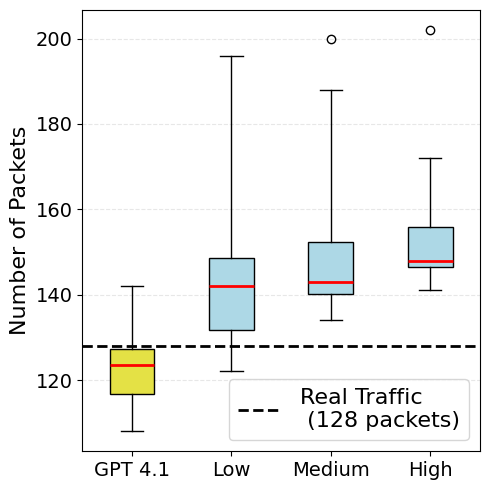

In [31]:
plt.figure(figsize=(5, 5))

# Create boxplot with editable patches
bp = plt.boxplot(num_pac, labels=labels, whis=3, patch_artist=True)

# Colors for each box
box_colors = [
    "#e4e145",   # GPT 4.1 - yellowish
    "#ADD8E6",   # GPT 5 Low - light blue
    "#ADD8E6",   # GPT 5 Medium - light blue
    "#ADD8E6"    # GPT 5 High - light blue
]

# Apply colors to boxes
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)

# # Color the boxes (light blue)
# for box in bp['boxes']:
#     box.set(facecolor="#ADD8E6")  # light blue

# Color the median line (red)
for median in bp['medians']:
    median.set(color="red", linewidth=2)

# ⭐ Add horizontal line at real traffic value 128
plt.axhline(y=128, color='black', linestyle='--', linewidth=2, label='Real Traffic \n (128 packets)')

plt.ylabel("Number of Packets", fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)

# Optional: show legend
plt.legend(fontsize=16)

plt.tight_layout()
plt.savefig("gpt5_num_pac.png", dpi=300)
plt.show()


## JSD VALUES

C:\Users\nkelesoglu\AppData\Local\Temp\ipykernel_13036\1202528477.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(JSD, labels=labels, patch_artist=True)


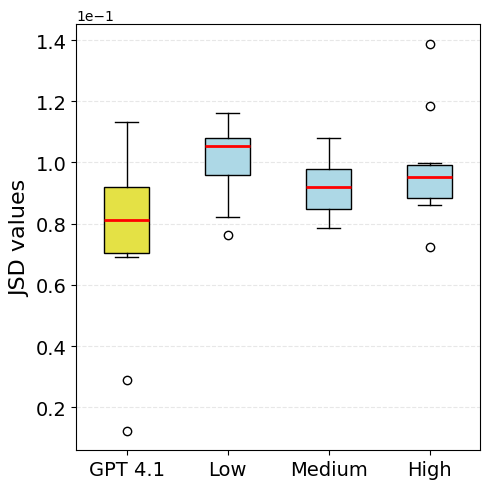

In [32]:
plt.figure(figsize=(5, 5))

# Create boxplot with editable patches
bp = plt.boxplot(JSD, labels=labels, patch_artist=True)

labels = ["Real Traffic", "GPT 4.1", "GPT 5\n Low", "GPT 5\n Medium", "GPT 5\n High"]


# Colors for each box
box_colors = [
    "#e4e145",   # GPT 4.1 - yellowish
    "#ADD8E6",   # GPT 5 Low - light blue
    "#ADD8E6",   # GPT 5 Medium - light blue
    "#ADD8E6"    # GPT 5 High - light blue
]

# Apply colors to boxes
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)

# Median line in red
for median in bp['medians']:
    median.set(color="red", linewidth=2)

plt.ylabel("JSD values", fontsize=16)

# Scientific notation for y-axis
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.savefig("gpt5_jsd.png", dpi=300)
plt.show()


# INTER ARRIVAL TIMES

In [259]:
# low_intervals.sort()
# medium_intervals.sort()
# high_intervals.sort()

C:\Users\nkelesoglu\AppData\Local\Temp\ipykernel_13036\1126565408.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(all_intervals, labels=labels, patch_artist=True)


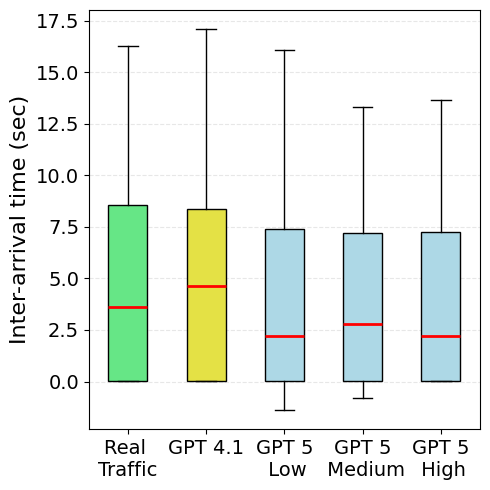

In [33]:
import matplotlib.pyplot as plt

all_intervals = [
    Real_Inter_Arrival, 
    gpt41_intervals, 
    low_intervals, 
    medium_intervals, 
    high_intervals
]

labels = ["Real \nTraffic", "GPT 4.1", "GPT 5\n Low", "GPT 5\n Medium", "GPT 5\n High"]

plt.figure(figsize=(5,5))

bp = plt.boxplot(all_intervals, labels=labels, patch_artist=True)

# ---- Set box colors ----
box_colors = [
    "#66e686",   # Real traffic - blue
    "#e4e145",   # GPT 4.1 - orange
    "#ADD8E6",   # GPT 5 Low - light blue
    "#ADD8E6",   # GPT 5 Medium - light blue
    "#ADD8E6"    # GPT 5 High - light blue
]

for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)

# ---- Median color ----
for median in bp['medians']:
    median.set(color="red", linewidth=2)

plt.ylabel("Inter-arrival time (sec)", fontsize=16)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("gpt_inter_arrival_boxplot.png", dpi=300)
plt.show()
